In [8]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

con = duckdb.connect('../olist.duckdb', read_only=True)

In [9]:
con.sql("SELECT * FROM mart_rfm_segments LIMIT 5").df()

,customer_unique_id,n_orders,total_spent,last_order_date,recency_days,r_score,f_score,m_score,customer_segment
0,317cfc692e3f86c45c95697c61c853a6,1,9.59,2018-08-25 21:20:50,4,5,1,1,New Customers
1,bd06ce0e06ad77a7f681f1a4960a3cc6,1,10.07,2017-09-13 19:13:20,350,2,4,1,Others
2,b33336f46234b24a613ad9064d13106d,1,10.89,2018-06-21 20:29:25,69,5,4,1,Loyal Customers
3,2878e5b88167faab17d4fb83a986d38b,1,11.63,2017-10-29 20:28:51,304,2,1,1,Lost
4,6f5b9d1cdccc4d28f0483a612edecacf,1,11.63,2017-09-02 16:05:34,361,2,3,1,Others


**Visualisation 1 — Répartition des segments (bar chart)**

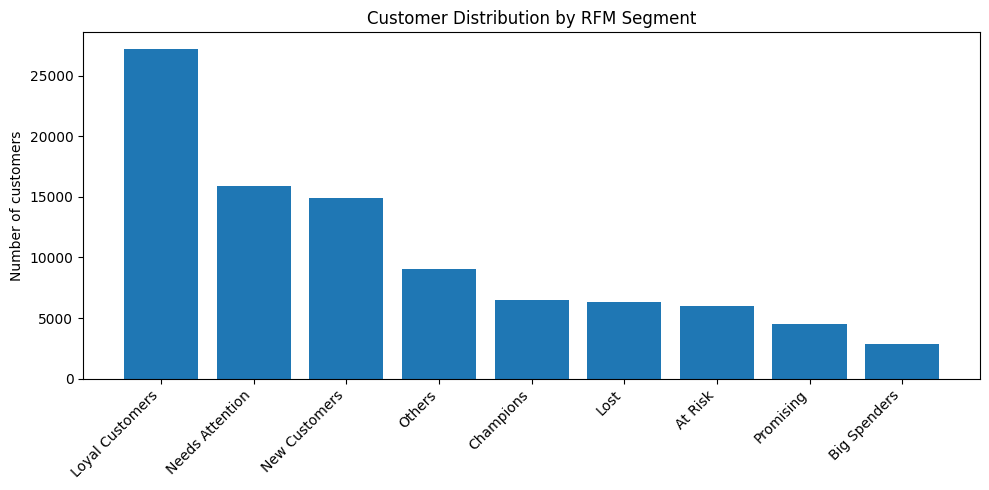

In [10]:
segment_counts = con.sql("""
    SELECT customer_segment, COUNT(*) as n_customers
    FROM mart_rfm_segments
    GROUP BY customer_segment
    ORDER BY n_customers DESC
""").df()

plt.figure(figsize=(10, 5))
plt.bar(segment_counts['customer_segment'], segment_counts['n_customers'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('Number of customers')
plt.title('Customer Distribution by RFM Segment')
plt.tight_layout()
plt.show()

**Visualisation 2 — Montant moyen dépensé par segment**

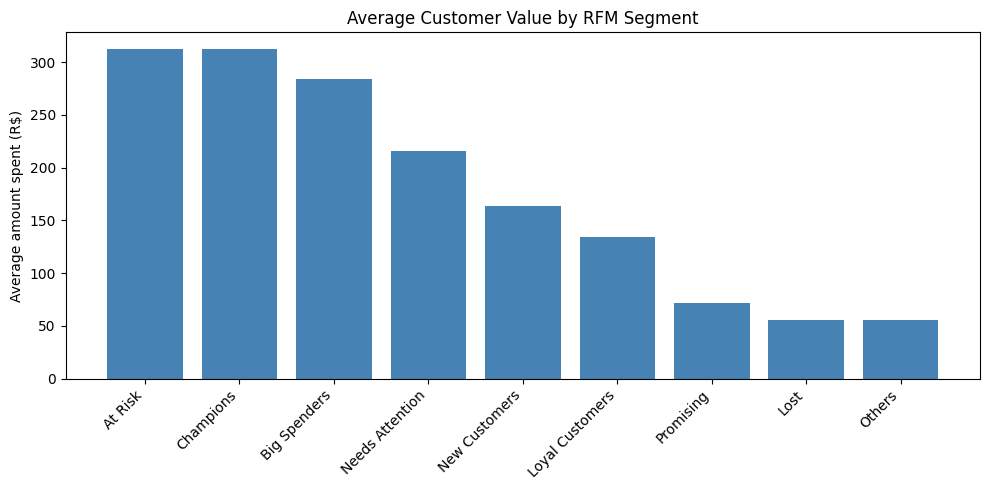

In [11]:
segment_value = con.sql("""
    SELECT 
        customer_segment, 
        COUNT(*) as n_customers,
        ROUND(AVG(total_spent), 2) as avg_spent,
        ROUND(SUM(total_spent), 2) as total_revenue
    FROM mart_rfm_segments
    GROUP BY customer_segment
    ORDER BY avg_spent DESC
""").df()

plt.figure(figsize=(10, 5))
plt.bar(segment_value['customer_segment'], segment_value['avg_spent'], color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Average amount spent (R$)')
plt.title('Average Customer Value by RFM Segment')
plt.tight_layout()
plt.show()

**Key observation**: Champions and At Risk customers show nearly identical 
average spending (~R$312-313), despite being on opposite ends of the recency 
dimension. This means At Risk customers are not simply "less valuable" 
customers who never mattered, they are high-value customers who have 
gone quiet. This makes them a strong candidate for a targeted reactivation 
campaign, since the financial upside is comparable to retaining a Champion.